# Matching experiment comparison

Observations from matching experiments are loaded from MongoDB, and node and relation matching quality is compared across models.

In [43]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pymongo import MongoClient

# The project directory is added so src can be imported from Jupyter.
sys.path.insert(0, str(next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src/config.py").is_file()
)))
from src.config import BASE_URL

EXPERIMENTS = {
    "matching-gpt5-6-luna": "GPT-5.6 Luna",
    "glm-5-3-flash-matching": "GLM-5.3 Flash",
    "qwen3-8-flash-matching": "Qwen3-8 Flash",
    "gemini-3-5-flash-lite-matching": "Gemini 3.5 Flash Lite",
}
MODEL_COLORS = {
    "GPT-5.6 Luna": "#1f77b4",
    "GLM-5.3 Flash": "#ff7f0e",
    "Qwen3-8 Flash": "#9467bd",
    "Gemini 3.5 Flash Lite": "#d62728",
}
COLLECTION_NAME = "matching_eval"
MONGODB_URI = os.getenv(
    "MONGODB_URI",
    "mongodb://127.0.0.1:27017/llm_uml_evaluator?replicaSet=rs0",
)

FIGURES_DIR = BASE_URL / "eval/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

The URI is read from the `MONGODB_URI` environment variable. JupyterLab is started with `uv run --env-file .env --group eval jupyter lab`.

In [44]:
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
try:
    collection = client.get_default_database()[COLLECTION_NAME]
    documents = list(
        collection.find(
            {"experiment_name": {"$in": list(EXPERIMENTS)}},
            {
                "experiment_name": 1,
                "sample": 1,
                "mutation": 1,
                "nodes": 1,
                "relations": 1,
            },
        )
    )
finally:
    client.close()

loaded_experiments = {document["experiment_name"] for document in documents}
if missing := set(EXPERIMENTS).difference(loaded_experiments):
    raise ValueError(f"No observations found for: {sorted(missing)}")

pd.Series(
    (document["experiment_name"] for document in documents),
    name="experiment_name",
).value_counts().rename("observations")

experiment_name
matching-gpt5-6-luna              180
qwen3-8-flash-matching            180
gemini-3-5-flash-lite-matching    180
glm-5-3-flash-matching            180
Name: observations, dtype: int64

## Metric calculation

A match is a `(reference_uid, candidate_uid)` pair. The formulas are applied separately to node matches and relation matches:

- `TP`: a returned pair that is also expected;
- `FP`: a returned pair that is not expected;
- `FN`: an expected pair that was not returned.

```text
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1        = 2 × Precision × Recall / (Precision + Recall)
          = 2TP / (2TP + FP + FN)
```

The final, algebraically equivalent F1 formula is used. A metric with a zero denominator remains undefined (`NaN`) and is excluded from the mean.

In [45]:
df = pd.json_normalize(documents).rename(
    columns={
        "nodes.true_positive": "nodes_tp",
        "nodes.false_positive": "nodes_fp",
        "nodes.false_negative": "nodes_fn",
        "relations.true_positive": "relations_tp",
        "relations.false_positive": "relations_fp",
        "relations.false_negative": "relations_fn",
    }
)

required_columns = {
    "experiment_name",
    "sample",
    "mutation",
    "nodes_tp",
    "nodes_fp",
    "nodes_fn",
    "relations_tp",
    "relations_fp",
    "relations_fn",
}
if missing := required_columns.difference(df.columns):
    raise ValueError(f"Missing columns: {sorted(missing)}")

df["model"] = df["experiment_name"].map(EXPERIMENTS)

for component in ("nodes", "relations"):
    tp = df[f"{component}_tp"]
    fp = df[f"{component}_fp"]
    fn = df[f"{component}_fn"]
    precision_denominator = tp + fp
    recall_denominator = tp + fn
    f1_denominator = 2 * tp + fp + fn
    df[f"{component}_precision"] = tp / precision_denominator.where(
        precision_denominator.ne(0)
    )
    df[f"{component}_recall"] = tp / recall_denominator.where(
        recall_denominator.ne(0)
    )
    df[f"{component}_f1"] = 2 * tp / f1_denominator.where(
        f1_denominator.ne(0)
    )

df.head()

,_id,experiment_name,sample,mutation,nodes_tp,nodes_fp,nodes_fn,relations_tp,relations_fp,relations_fn,model,nodes_precision,nodes_recall,nodes_f1,relations_precision,relations_recall,relations_f1
0,matching-gpt5-6-luna_1_0_1,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
1,matching-gpt5-6-luna_1_0_2,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
2,matching-gpt5-6-luna_1_0_3,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
3,matching-gpt5-6-luna_1_1_1,matching-gpt5-6-luna,1,1,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
4,matching-gpt5-6-luna_1_1_2,matching-gpt5-6-luna,1,1,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0


## Coverage check

The table shows the number of repetitions for each `model × sample × mutation` combination.

In [46]:
coverage = (
    df.groupby(["model", "sample", "mutation"], sort=False)
    .size()
    .unstack(fill_value=0)
)
display(coverage)
display(
    df.groupby(["model", "mutation"], sort=False)[
        ["nodes_f1", "relations_f1"]
    ].agg(["mean", "std", "count"]).round(3)
)

mutation                      0  1  2  3  4  5
model                 sample                  
GPT-5.6 Luna          1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
Qwen3-8 Flash         1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
Gemini 3.5 Flash Lite 1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
GLM-5.3 Flash         1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3

nodes_f1              relations_f1             
                                   mean    std count         mean    std count
model                 mutation                                                
GPT-5.6 Luna          0           1.000  0.000    30        1.000  0.000    30
                      1           1.000  0.000    30        0.998  0.012    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        1.000  0.000    30
                      5           1.000  0.000    30        1.000  0.000    30
Qwen3-8 Flash         0           0.999  0.007    30        1.000  0.000    30
                      1           0.931  0.253    30        0.931  0.253    30
                      2           0.932  0.236    30        0.972  0.154    30
                      3           0.932  0.253    30        0.965  0.182    30
                      4           0.965  0.182    30        0.950  0.199    30
                      5           0.999  0.007    30        1.000  0.000    30
Gemini 3.5 Flash Lite 0           1.000  0.000    30        1.000  0.000    30
                      1           0.997  0.014    30        0.943  0.117    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        1.000  0.000    30
                      5           1.000  0.000    30        1.000  0.000    30
GLM-5.3 Flash         0           1.000  0.000    30        1.000  0.000    30
                      1           1.000  0.000    30        0.994  0.026    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        0.981  0.077    30
                      5           1.000  0.000    30        1.000  0.000    30

## Quality by mutation

Bars show mean F1 for each model; error bars span the minimum and maximum F1 observed across repetitions.

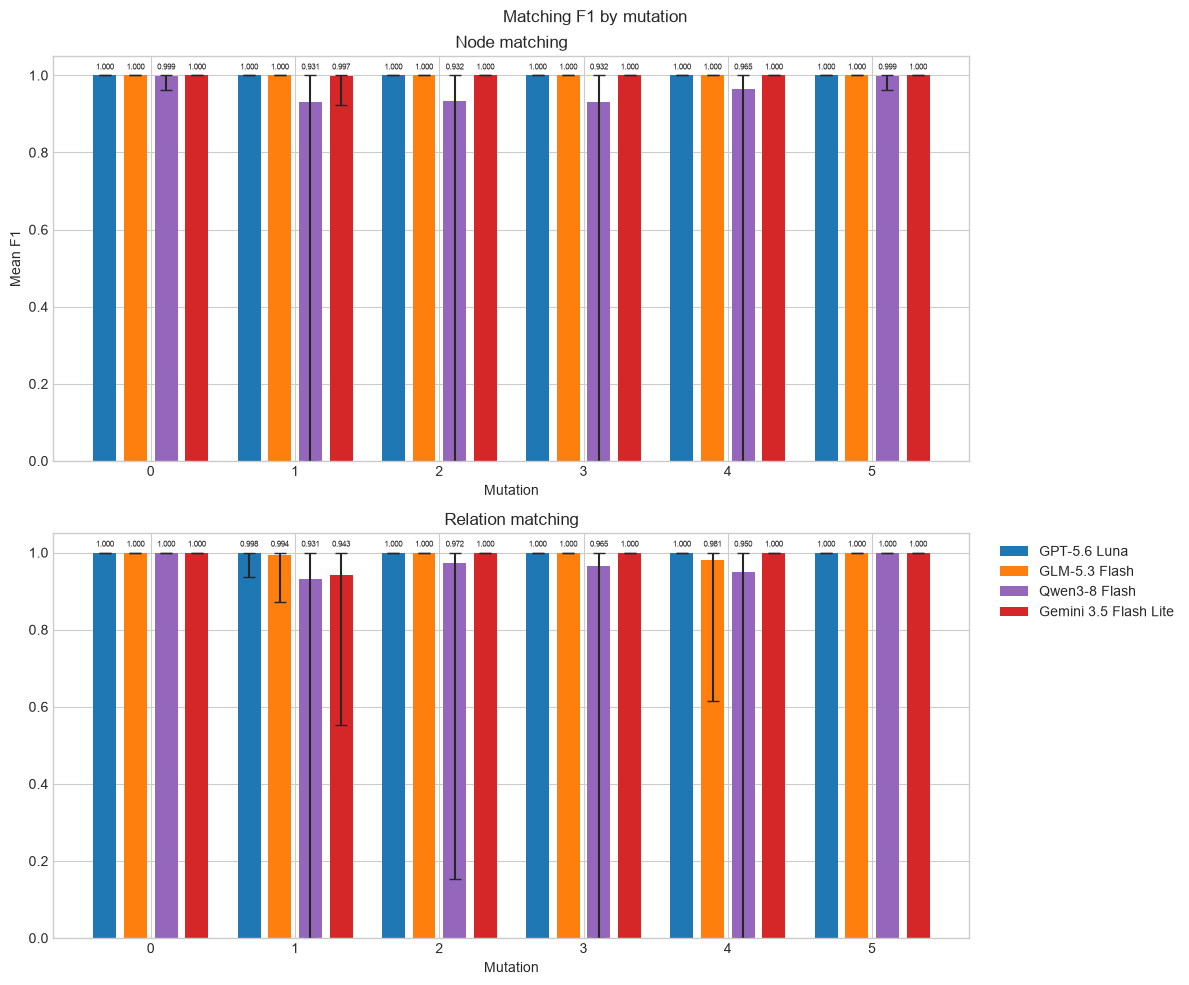

In [47]:
f1_by_mutation = df.groupby(["model", "mutation"], sort=False)[
    ["nodes_f1", "relations_f1"]
].agg(
    ["mean", "min", "max"]
)
f1_means = f1_by_mutation.xs("mean", axis=1, level=1)
f1_mins = f1_by_mutation.xs("min", axis=1, level=1)
f1_maxs = f1_by_mutation.xs("max", axis=1, level=1)
ylim = (0, 1.05)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharey=True)
for ax, component, title in (
    (axes[0], "nodes", "Node matching"),
    (axes[1], "relations", "Relation matching"),
):
    means = (
        f1_means[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    minimums = (
        f1_mins[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    maximums = (
        f1_maxs[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    errors = {
        model: [
            (means[model] - minimums[model]).to_numpy(),
            (maximums[model] - means[model]).to_numpy(),
        ]
        for model in means
    }
    means.plot.bar(
        ax=ax,
        yerr=errors,
        capsize=4,
        rot=0,
        width=0.85,
        color=[MODEL_COLORS[model] for model in means],
    )
    for container in ax.containers:
        if not hasattr(container, "datavalues"):
            continue
        for bar in container:
            original_width = bar.get_width()
            bar.set_width(original_width * 0.75)
            bar.set_x(bar.get_x() + original_width * 0.125)
        ax.bar_label(
            container,
            labels=[f"{value:.3f}" for value in container.datavalues],
            padding=3,
            fontsize=6,
        )
    ax.set(title=title, xlabel="Mutation", ylim=ylim)
axes[0].set_ylabel("Mean F1")
axes[0].get_legend().remove()
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Matching F1 by mutation")
fig.tight_layout()
plt.show()

### Save figure

In [48]:
fig.savefig(
    FIGURES_DIR / "matching_f1_by_mutation.png",
    dpi=300,
    bbox_inches="tight",
)

## Error profile

Mean number of false (`FP`) and missed (`FN`) matches per observation.

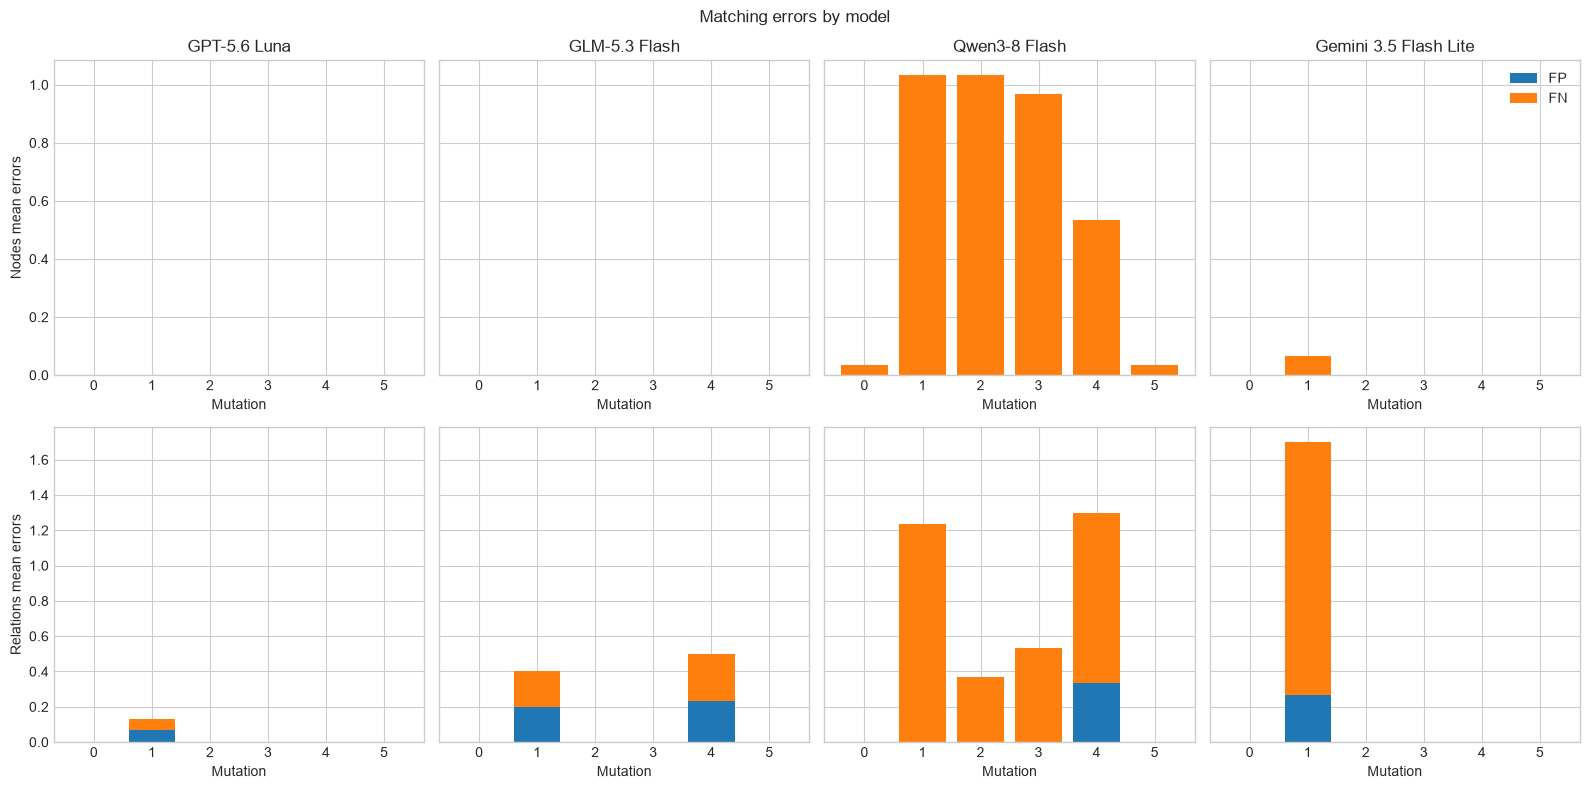

In [49]:
errors = df.groupby(["model", "mutation"], sort=False)[
    ["nodes_fp", "nodes_fn", "relations_fp", "relations_fn"]
].mean()

fig, axes = plt.subplots(
    2, len(EXPERIMENTS), figsize=(4 * len(EXPERIMENTS), 8), sharey="row"
)
for row, (component, row_title) in enumerate(
    (("nodes", "Nodes"), ("relations", "Relations"))
):
    for column, model in enumerate(EXPERIMENTS.values()):
        ax = axes[row, column]
        values = errors.loc[model]
        ax.bar(values.index, values[f"{component}_fp"], label="FP")
        ax.bar(
            values.index,
            values[f"{component}_fn"],
            bottom=values[f"{component}_fp"],
            label="FN",
        )
        ax.set(title=model if row == 0 else None, xlabel="Mutation")
    axes[row, 0].set_ylabel(f"{row_title} mean errors")
axes[0, -1].legend()
fig.suptitle("Matching errors by model")
fig.tight_layout()
plt.show()

### Save figure

In [50]:
fig.savefig(
    FIGURES_DIR / "matching_errors_by_model.png",
    dpi=300,
    bbox_inches="tight",
)

## Exact case rate

An observation is counted as exact when both FP and FN are zero for node matches and relation matches. Every expected pair must therefore be returned, and no unexpected pair may be introduced. A single matching error is sufficient for failure, even when F1 remains high.

The proportion of exact observations is calculated separately for each model and mutation type. Correct and evaluated observation counts are also reported. Repeated runs measure consistency on the same ten diagrams; they are not additional independent diagrams. The control is included as a baseline. Errors on unchanged elements also cause failure, so the affected element cannot be identified from this metric alone.


,,correct,evaluated,exact_case_rate
mutation,model,,,
0,GPT-5.6 Luna,30,30,100.0%
1,GPT-5.6 Luna,29,30,96.7%
2,GPT-5.6 Luna,30,30,100.0%
3,GPT-5.6 Luna,30,30,100.0%
4,GPT-5.6 Luna,30,30,100.0%
5,GPT-5.6 Luna,30,30,100.0%
0,Qwen3-8 Flash,29,30,96.7%
1,Qwen3-8 Flash,26,30,86.7%
2,Qwen3-8 Flash,26,30,86.7%


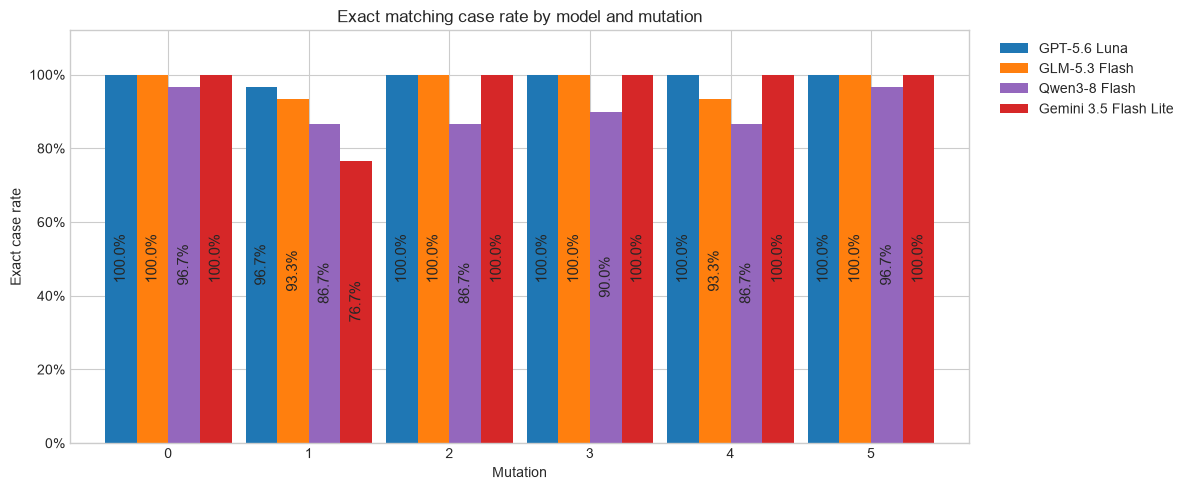

In [51]:
df["exact_case"] = df[
    ["nodes_fp", "nodes_fn", "relations_fp", "relations_fn"]
].eq(0).all(axis=1)

exact_summary = (
    df.groupby(["mutation", "model"], sort=False)["exact_case"]
    .agg(correct="sum", evaluated="count", exact_case_rate="mean")
)
display(exact_summary.style.format({"exact_case_rate": "{:.1%}"}))

exact_rates = (
    exact_summary["exact_case_rate"]
    .unstack("model")
    .sort_index()
    .reindex(columns=EXPERIMENTS.values())
)
fig, ax = plt.subplots(figsize=(12, 5))
exact_rates.plot.bar(
    ax=ax,
    rot=0,
    width=0.9,
    color=[MODEL_COLORS[model] for model in exact_rates],
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:.1%}" for value in container.datavalues],
        label_type="center",
        rotation=90,
        fontsize=10.5,
    )
ax.set(
    title="Exact matching case rate by model and mutation",
    xlabel="Mutation",
    ylabel="Exact case rate",
    ylim=(0, 1.12),
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


### Save figure

In [52]:
fig.savefig(
    FIGURES_DIR / "matching_exact_case_rate.png",
    dpi=300,
    bbox_inches="tight",
)
